In [1]:
import jax
from jax import grad, hessian, vmap
import jax.numpy as jnp

from scipy.optimize import least_squares
import matplotlib.pyplot as plt

import numpy as np
from numpy.random import normal, uniform

import tqdm
import sys

▶ Solving instance 1/5000 …
▶ Solving instance 2/5000 …
▶ Solving instance 3/5000 …
▶ Solving instance 4/5000 …
▶ Solving instance 5/5000 …
▶ Solving instance 6/5000 …
▶ Solving instance 7/5000 …
▶ Solving instance 8/5000 …
▶ Solving instance 9/5000 …
▶ Solving instance 10/5000 …
▶ Solving instance 11/5000 …
▶ Solving instance 12/5000 …
▶ Solving instance 13/5000 …
▶ Solving instance 14/5000 …
▶ Solving instance 15/5000 …
▶ Solving instance 16/5000 …
▶ Solving instance 17/5000 …
▶ Solving instance 18/5000 …
▶ Solving instance 19/5000 …
▶ Solving instance 20/5000 …
▶ Solving instance 21/5000 …
▶ Solving instance 22/5000 …
▶ Solving instance 23/5000 …
▶ Solving instance 24/5000 …
▶ Solving instance 25/5000 …
▶ Solving instance 26/5000 …
▶ Solving instance 27/5000 …
▶ Solving instance 28/5000 …
▶ Solving instance 29/5000 …
▶ Solving instance 30/5000 …
▶ Solving instance 31/5000 …
▶ Solving instance 32/5000 …
▶ Solving instance 33/5000 …
▶ Solving instance 34/5000 …
▶ Solving instance 35/5

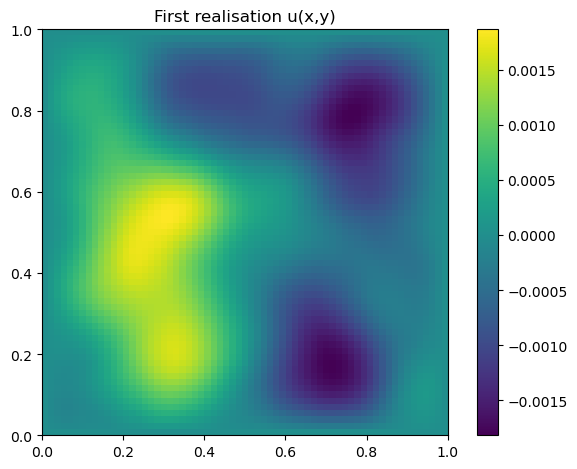

Tensor saved to fem_solutions_N64_5000.pt


In [2480]:
import os, math, torch, matplotlib.pyplot as plt       # noqa: E401
torch.set_default_dtype(torch.float64)
torch.manual_seed(0)                                   # reproducible first draw

# --------------------------------------------------------------------------- 
# ---------------  FEM building blocks (identical to previous) -------------- 
# ---------------------------------------------------------------------------

def create_mesh(N_sqrt: int):
    xs = torch.linspace(0.0, 1.0, N_sqrt + 1)
    ys = torch.linspace(0.0, 1.0, N_sqrt + 1)
    xv, yv = torch.meshgrid(xs, ys, indexing='ij')
    coords = torch.stack([xv.flatten(), yv.flatten()], dim=1)
    tris = []
    for i in range(N_sqrt):
        for j in range(N_sqrt):
            n0 = i*(N_sqrt+1)+j
            n1 = (i+1)*(N_sqrt+1)+j
            n2 = i*(N_sqrt+1)+j+1
            n3 = (i+1)*(N_sqrt+1)+j+1
            tris.append([n0,n1,n2])
            tris.append([n1,n3,n2])
    return coords, torch.tensor(tris, dtype=torch.long)

def fem_geometry(coords, tris):
    p0, p1, p2 = coords[tris[:,0]], coords[tris[:,1]], coords[tris[:,2]]
    area2  = (p1[:,0]-p0[:,0])*(p2[:,1]-p0[:,1]) - (p2[:,0]-p0[:,0])*(p1[:,1]-p0[:,1])
    area   = 0.5*area2.abs()
    grads  = torch.empty((tris.shape[0],3,2), dtype=torch.float64)
    grads[:,0,0], grads[:,0,1] = (p1[:,1]-p2[:,1])/area2, (p2[:,0]-p1[:,0])/area2
    grads[:,1,0], grads[:,1,1] = (p2[:,1]-p0[:,1])/area2, (p0[:,0]-p2[:,0])/area2
    grads[:,2,0], grads[:,2,1] = (p0[:,1]-p1[:,1])/area2, (p1[:,0]-p0[:,0])/area2
    return grads, area

def smooth_gaussian_field(N_sqrt, lengthscale=0.15):
    noise  = torch.randn((N_sqrt+1, N_sqrt+1))
    ksize  = 9
    sigma  = lengthscale*N_sqrt
    idx    = torch.arange(ksize)-ksize//2
    k1     = torch.exp(-0.5*(idx/sigma)**2);  k1 /= k1.sum()
    kernel = (k1[:,None]@k1[None,:])/k1.sum()
    fgrid  = torch.nn.functional.conv2d(
                 noise[None,None], kernel[None,None],
                 padding=ksize//2).squeeze()
    return fgrid.flatten(), fgrid.clone()

def solve(N_sqrt=32, lengthscale=1.5, max_iter=120):
    coords, tris = create_mesh(N_sqrt)
    grads, area  = fem_geometry(coords, tris)
    f, f_grid           = smooth_gaussian_field(N_sqrt, lengthscale)

    bdry = (coords[:,0]==0)|(coords[:,0]==1)|(coords[:,1]==0)|(coords[:,1]==1)
    interior = (~bdry).nonzero(as_tuple=True)[0]
    n_int = interior.numel()
    index = -torch.ones(coords.shape[0], dtype=torch.long)
    index[interior] = torch.arange(n_int)

    def full(u_int):
        u = torch.zeros(coords.shape[0], dtype=torch.float64)
        u[interior] = u_int
        return u

    u_int = torch.zeros(n_int, dtype=torch.float64, requires_grad=True)
    opt   = torch.optim.LBFGS([u_int], max_iter=max_iter,
                              tolerance_grad=1e-7,
                              line_search_fn='strong_wolfe')

    def closure():
        opt.zero_grad()
        u  = full(u_int)
        ut = u[tris]
        grad_u = (ut.unsqueeze(2)*grads).sum(1)
        e = 0.5*grad_u.square().sum(1) + 0.25*ut.mean(1)**4 - f[tris].mean(1)*ut.mean(1)
        energy = (e*area).sum()
        energy.backward()
        return energy
    opt.step(closure)
    return full(u_int), f                # return nodal vector only

# --------------------------------------------------------------------------- 
# -------------------------  dataset generator ------------------------------ 
# ---------------------------------------------------------------------------

def build_dataset(N_sqrt=24, lengthscale=1,
                  N_solutions=10, max_iter=120, plot_first=True):
    """
    Compute `N_solutions` independent FEM solutions and return the
    column‑stacked tensor  solutions_tensor.

    Returns
    -------
    solutions_tensor : torch.Tensor, shape ((N+1)**2, N_solutions)
    """
    M = (N_sqrt+1)**2
    solutions_tensor = torch.zeros(M, N_solutions, dtype=torch.float64)
    rhs_tensor       = torch.zeros((M, N_solutions), dtype=torch.float64)

    for k in range(N_solutions):
        print(f"▶ Solving instance {k+1}/{N_solutions} …", flush=True)
        u, f = solve(N_sqrt, lengthscale, max_iter)
        solutions_tensor[:, k] = u
        rhs_tensor[:, k]       = f
    print("✓ Done.")

    if plot_first:
        u0 = solutions_tensor[:, 0].view(N_sqrt+1, N_sqrt+1).t()
        plt.figure()
        plt.imshow(u0.detach().numpy(), origin='lower', extent=[0,1,0,1])
        plt.title("First realisation u(x,y)")
        plt.colorbar(); plt.tight_layout(); plt.show()

    return solutions_tensor, rhs_tensor

# --------------  example invocation as a script ----------------------------
if __name__ == "__main__":
    N_sqrt            = 64          # mesh resolution  (≈ 1 k DOFs)
    N_solutions  = 5000           # how many draws you want
    solutions, rhs_tensor = build_dataset(N_sqrt, lengthscale=0.2,
                              N_solutions=N_solutions, max_iter=100)
    #torch.save(solutions, f"fem_solutions_N{N}_{N_solutions}.pt")
    print(f"Tensor saved to fem_solutions_N{N_sqrt}_{N_solutions}.pt")

In [2481]:
# Initial vorticity (Taylor-Green vortex)
xs = torch.linspace(0.0, 1.0, N_sqrt + 1)
ys = torch.linspace(0.0, 1.0, N_sqrt + 1)
X, Y = torch.meshgrid(xs, ys)

grid = torch.concatenate((X.flatten()[:,None],Y.flatten()[:,None]),axis=1)

boundary_mask = (X == xs[0]) | (X == xs[-1]) | (Y == ys[0]) | (Y == ys[-1])
# Flatten the mask
boundary_indices = torch.where(boundary_mask.flatten())[0]

interior_points = grid[~torch.isin(torch.arange((N_sqrt+1)**2), boundary_indices)]

# Separate boundary points and interior points
boundary_points = grid[boundary_indices]
# Rearrange grid with boundary points at the bottom
rearranged_grid = torch.concatenate((interior_points, boundary_points), axis=0)

# Convert to torch tensor to obtain indices of interior points
interior_mask = ~boundary_mask.flatten()
interior_indices = torch.where(interior_mask)[0]

#Interior indices, then boundary indices
rearranged_indices = torch.concatenate((interior_indices,boundary_indices),axis=0)


In [2482]:
#Ground truth solution

alpha = 1
m = 3

def u(x1,x2):
  #return jnp.sin(jnp.pi*x1)*jnp.sin(jnp.pi*x2)+2*jnp.sin(4*jnp.pi*x1)*jnp.sin(4*jnp.pi*x2)
  return 0.5 * torch.sin(torch.pi * x1) * torch.sin(torch.pi * x2) + torch.sin(2.0*torch.pi * x1)*torch.sin(2.0*torch.pi * x2)
#RHS

def f(x1,x2):
  term1 = -torch.pi**2 * torch.sin(torch.pi * x1) * torch.sin(torch.pi * x2)
  term2 = -8 * torch.pi**2 * torch.sin(2 * torch.pi * x1) * torch.sin(2 * torch.pi * x2)
  return -(term1+term2)+alpha*(u(x1, x2)**m)

def g(x1,x2):
  return u(x1,x2)

In [2483]:
# Define a real valued kernel kappa(x, y; sigma) \to R
def kernel_gaussian(x1, y1, x2, y2, sigma):
    # x,y are 2D input row vectors
    # sigma is the variance parameter
    return jnp.exp(-(1/(2*sigma**2))*( (x1- y1)**2 + (x2 - y2)**2 ))

# define derivatives of the kernel
def kernel_gaussian_lap(x1, y1, x2, y2, sigma):
    val = grad(grad(kernel_gaussian, 0), 0)(x1, y1, x2, y2, sigma)
    val += grad(grad(kernel_gaussian, 2), 2)(x1, y1, x2, y2, sigma)
    return val

def kernel_gaussian_lap_y(x1, y1, x2, y2, sigma):
    val = grad(grad(kernel_gaussian, 1), 1)(x1, y1, x2, y2, sigma)
    val += grad(grad(kernel_gaussian, 3), 3)(x1, y1, x2, y2, sigma)
    return val

def kernel_gaussian_lap2(x1, y1, x2, y2, sigma):
    val = grad(grad(kernel_gaussian_lap_y, 0), 0)(x1, y1, x2, y2, sigma)
    val += grad(grad(kernel_gaussian_lap_y, 2), 2)(x1, y1, x2, y2, sigma)
    return val

In [2484]:
def kernel_matern(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = (1+jnp.sqrt(5)*r/sigma+5/3*r**2/sigma**2)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

def kernel_matern_lap(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K_dx1_2 = -5/(3*sigma**3)*(sigma+jnp.sqrt(5)*r-5*(x1-y1)**2/sigma)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  K_dx2_2 = -5/(3*sigma**3)*(sigma+jnp.sqrt(5)*r-5*(x2-y2)**2/sigma)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  K = K_dx1_2+K_dx2_2
  return K

def kernel_matern_lap2(x1,y1,x2,y2,sigma):
  r = jnp.sqrt((x1-y1)**2+(x2-y2)**2)
  K = -5/(3*sigma**3)*(35*jnp.sqrt(5)*r/sigma**2-40/sigma-25*r**2/sigma**3)*jnp.exp(-jnp.sqrt(5)*r/sigma)
  return K

In [2537]:
def K_Gaussian(X,Y,sigma,reg=False,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_gaussian(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Matern(X,Y,sigma,reg=False,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_matern(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Gaussian_Lap(X,Y,sigma,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_gaussian_lap(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix = jnp.reshape(val, (size, size2))
  return K_matrix

def K_Gaussian_Lap2(X,Y,sigma,reg=False,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_gaussian_lap2(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix

def K_Matern_Lap(X,Y,sigma,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_matern_lap(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix = jnp.reshape(val, (size,size2))

  return K_matrix

def K_Matern_Lap2(X,Y,sigma,reg=False,nugget=10**-10):
  size=len(X[:,0])
  size2=len(Y[:,0])
  X0=jnp.transpose(jnp.tile(X[:,0],(size2,1)))
  X1=jnp.transpose(jnp.tile(X[:,1],(size2,1)))
  Y0=jnp.transpose(jnp.tile(Y[:,0],(size,1)))
  Y1=jnp.transpose(jnp.tile(Y[:,1],(size,1)))

  val = vmap(lambda s1, t1, s2, t2: kernel_matern_lap2(s1, t1,s2,t2,sigma))(X0.flatten(),jnp.transpose(Y0).flatten(),X1.flatten(),jnp.transpose(Y1).flatten())

  K_matrix=jnp.reshape(val,(size,size2))
  if reg==True:
    K_matrix+=+nugget*jnp.eye(size)
  return K_matrix


In [2487]:
# vectorized construction of Theta, the kernel matrix
def assembly_Theta(X_domain, X_boundary, nugget, set_sigma):

    N_domain = X_domain.shape[0]
    N_boundary = X_boundary.shape[0]
    N = N_domain+N_boundary

    K = jnp.zeros((2*N_domain + N_boundary, 2*N_domain + N_boundary))
    grid = jnp.vstack([X_domain,X_boundary])

    #Pointwise evaluation of kernel + Laplacians

    K = K.at[:N,:N].set(K_Matern(grid,grid,sigma=set_sigma))
    K = K.at[N:N+N_domain,N:N+N_domain].set(K_Matern_Lap2(X_domain,X_domain,sigma=set_sigma))
    K = K.at[N:N+N_domain,:N].set(-K_Matern_Lap(X_domain,grid,sigma=set_sigma))
    K = K.at[:N,N:N+N_domain].set(K[N:N+N_domain,:N].T)

    # calculate trace
    trace1 = jnp.trace(K[:N, :N])
    trace2 = jnp.trace(K[N:, N:])
    ratio = trace2/trace1

    #add regularization term
    temp=jnp.concatenate((jnp.ones((1,N)),ratio*jnp.ones((1,N_domain))), axis=1)
    K = K + nugget*jnp.diag(temp[0])

    #Cholesky decomposition
    L = jnp.linalg.cholesky(K)

    return L, ratio, K


In [2488]:
N_domain_tot = interior_points.shape[0]
N_boundary_tot = boundary_points.shape[0]
N = N_domain_tot+N_boundary_tot

In [2489]:
# loss function
def J(z,rhs_f,bdy_g,L):
    ww = torch.cat((z,bdy_g, rhs_f-alpha*(z**m)),dim=0)

    ss = torch.linalg.solve(L.float(), ww.float().unsqueeze(1))
    ss = ss.squeeze(1)
    return torch.dot(ss, ss)

#grad_J=torch.autograd.grad(J)


def grad_J_torch(v, rhs_f, bdy_g, L):
    v = v.clone().detach().requires_grad_(True)
    L = L.float()
    loss = J(v, rhs_f, bdy_g, L)
    grad_v, = torch.autograd.grad(loss, v, create_graph=False)
    return grad_v


def Hessian_GN(v, L):
    """
    Approximated Hessian using Gauss–Newton method.
    Returns H = 2 * S^T S, where S = L @ mtx.
    """
    L = L.float()
    total_rows = N + N_domain_tot  # should equal N_total = 2999.
    mtx = torch.zeros((total_rows, N_domain_tot), dtype=v.dtype, device=v.device)

    I = torch.eye(N_domain_tot, dtype=v.dtype, device=v.device)

    mtx[:N_domain_tot, :] = I
    mtx[N:N+N_domain_tot, :] = -m*alpha*torch.diag(v**(m-1))
    
    S = torch.linalg.solve(L, mtx.float())
    return 2 * (S.t() @ S)


#Hessian_GN=torch.autograd.hessian(GN_J)

max_iter = 5
step_size = 1
set_sigma = 0.3
set_nugget = 1e-8

L_Gaussian, ratio, K = assembly_Theta(interior_points.detach().numpy(), boundary_points.detach().numpy(), set_nugget, set_sigma)

L_Gaussian = torch.from_numpy(np.array(L_Gaussian))
#K = torch.from_numpy(np.array(K))

In [2490]:
L_Gaussian

tensor([[nan, 0., 0.,  ..., 0., 0., 0.],
        [nan, nan, 0.,  ..., 0., 0., 0.],
        [nan, nan, nan,  ..., 0., 0., 0.],
        ...,
        [nan, nan, nan,  ..., nan, 0., 0.],
        [nan, nan, nan,  ..., nan, nan, 0.],
        [nan, nan, nan,  ..., nan, nan, nan]], dtype=torch.float32)

iter = 0 J = tensor(nan, dtype=torch.float32)
iter =  1 Gauss-Newton step size = 1  J =  tensor(nan, dtype=torch.float32)
iter =  2 Gauss-Newton step size = 1  J =  tensor(nan, dtype=torch.float32)
iter =  3 Gauss-Newton step size = 1  J =  tensor(nan, dtype=torch.float32)
iter =  4 Gauss-Newton step size = 1  J =  tensor(nan, dtype=torch.float32)
iter =  5 Gauss-Newton step size = 1  J =  tensor(nan, dtype=torch.float32)


Text(0.5, 1.0, 'Loss function history')

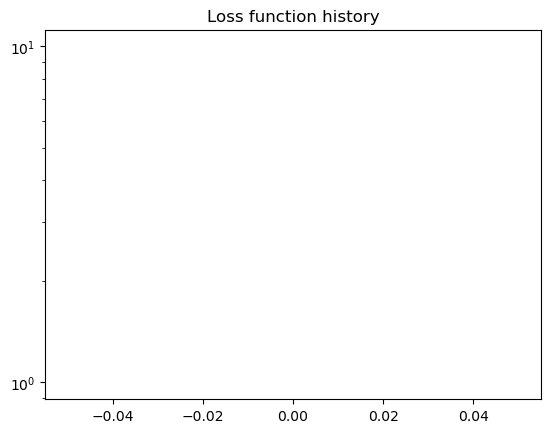

In [2491]:

def pde_solver(X_boundary, max_iter, step_size, initial_sol, rhs_f, L):
    bdy_g = u(X_boundary[:,0], X_boundary[:,1])

    sol = initial_sol
    J_hist = [] # history of loss function values
    J_now = J(sol,rhs_f,bdy_g,L)
    J_hist.append(J_now)

    print('iter = 0', 'J =', J_now) # print out history

    for iter_step in range(1, max_iter+1):
        H = Hessian_GN(sol, L)
        grad_val = grad_J_torch(sol, rhs_f, bdy_g, L)
        temp = torch.linalg.solve(H, grad_val.float())
        sol = sol - step_size*temp

        J_now = J(sol,rhs_f,bdy_g,L)
        J_hist.append(J_now)
        # print out history
        print('iter = ', iter_step, 'Gauss-Newton step size =', step_size, ' J = ', J_now)
    return sol, J_hist


initial_sol = torch.from_numpy(normal(0.0, 1.0, N_domain_tot)) # random initial guess

X_domain_tot = interior_points
X_boundary_tot = boundary_points

sol_classical, J_hist = pde_solver(X_boundary_tot, max_iter, step_size, initial_sol, rhs_f = f(X_domain_tot[:,0], X_domain_tot[:,1]),L = L_Gaussian)

plt.plot(np.arange(max_iter+1),J_hist)
plt.yscale("log")
plt.title('Loss function history')

In [2512]:
# err at collocation points

sol_truth = u(X_domain_tot[:,0], X_domain_tot[:,1])

L2_err_pts = torch.linalg.norm(sol_classical-sol_truth)/torch.linalg.norm(sol_truth)
max_err_pts = torch.max(torch.abs(sol_classical-sol_truth))



print('At collocation points, L2 err= ', L2_err_pts, ' max err=', max_err_pts)

At collocation points, L2 err=  tensor(nan)  max err= tensor(nan)


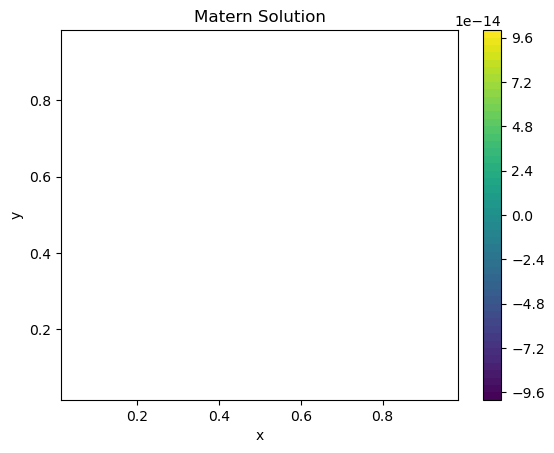

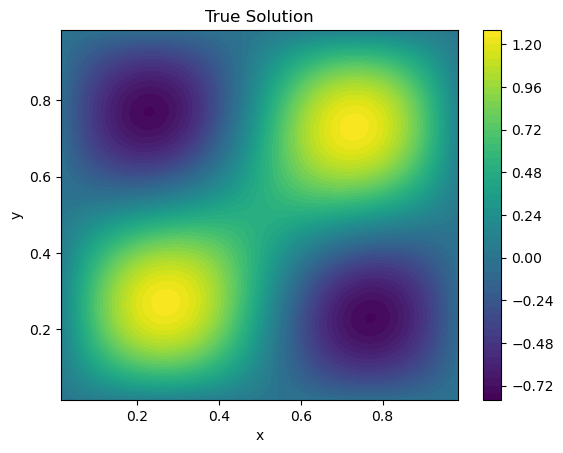

In [2513]:
# Use contourf or pcolormesh to display the 2D field.
x_int = xs[1:-1]
y_int = ys[1:-1]
X_int, Y_int = np.meshgrid(x_int,y_int)
cp = plt.contourf(X_int, Y_int, sol_classical.reshape((N_sqrt-1,N_sqrt-1)), levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Matern Solution')
plt.show()
cp = plt.contourf(X_int, Y_int, sol_truth.reshape((N_sqrt-1,N_sqrt-1)), levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('True Solution')
plt.show()

In [2493]:
solution_space = solutions[rearranged_indices]
f_vals = rhs_tensor[rearranged_indices][:N_domain_tot]

In [2515]:
used_solutions = 5000

#Stores solutions u_i and RHS f_i
solution_space_red = solution_space[:,:used_solutions]
f_vals_red = f_vals[:,:used_solutions]

#Constructing the empirical kernel

N = N_domain_tot+N_boundary_tot

K_Empirical = torch.zeros((N+N_domain_tot,N+N_domain_tot))

Neg_Lap = f_vals_red-solution_space_red[:N_domain_tot,:]**3


K_Empirical[:N,:N] = solution_space_red@solution_space_red.T
K_Empirical[N:,:N] = Neg_Lap@solution_space_red.T
K_Empirical[:N,N:] = K_Empirical[N:,:N].T
K_Empirical[N:,N:] = Neg_Lap@Neg_Lap.T

#Normalizing the kernel

K_Empirical= K_Empirical/used_solutions

#Adding nugget to Empirical kernel

trace1 = torch.trace(K_Empirical[:N, :N])
trace2 = torch.trace(K_Empirical[N:, N:])

ratio = trace2/trace1

eta = 0*10**-15

temp= torch.concatenate((torch.ones((1,N)),ratio*torch.ones((1,N_domain_tot))), axis=1)


#K_Empirical = torch.from_numpy(np.array(K))
K_Empirical = K_Empirical + eta*torch.diag(temp[0])
#Cholesky decomposition

#L_Empirical = torch.linalg.cholesky(K_Empirical)

In [2516]:
#threshold = torch.sum(K_Empirical.max(dim=0).values)/(np.sqrt(N_solutions)*N_solutions)
#K_Empirical = K_Empirical * (K_Empirical.abs() >= threshold)

In [2517]:
type(K)

jaxlib.xla_extension.ArrayImpl

In [2518]:
#from scipy.spatial.distance import cdist
#Maximin ordering -My own code (slower but I trust it more)
from torch import cdist

def maximin(x):
    init_indices = torch.arange(len(x))[:, None]

    # Append original indices to the point data
    x = torch.cat((x, init_indices.to(x.dtype)), dim=1)
    n = x.shape[0]

    # Create array to hold the final order
    indices = torch.zeros(n, dtype=torch.long)

    # Start with the first point arbitrarily
    indices[0] = 0
    A = x[0, :-1].unsqueeze(0)  # shape: (1, d)

    # Remove the first point from x
    mask = torch.ones(n, dtype=torch.bool)
    mask[0] = False
    x = x[mask]

    for i in range(1, n):
        dists = cdist(x[:, :-1], A)  # shape: (n-i, i)
        min_dists = torch.min(dists, dim=1).values  # (n-i,)
        maximizer = torch.argmax(min_dists)  # index in x

        indices[i] = int(x[maximizer, -1].item())  # store the original index
        A = torch.cat([A, x[maximizer, :-1].unsqueeze(0)], dim=0)

        # Remove selected row from x
        mask = torch.ones(x.size(0), dtype=torch.bool)
        mask[maximizer] = False
        x = x[mask]

    return indices


#Permutation map

P = torch.zeros(N+N_domain_tot)
grid = torch.vstack([X_domain_tot, X_boundary_tot])

P[:N] = maximin(grid)

P[N:] = torch.arange(N_domain_tot)

#Reordering points according to maximin ordering

#Lengthscale of x

def lengthscale(x):
  lengths = torch.ones(len(x[:,0]))
  lengths[0] = float('inf')

  for i in range(1,len(x[:,0])):
    lengths[i] = torch.min(cdist(x[i,:][None,:],x[:i,:]))

  return lengths

grid_reordered = grid[maximin(grid)]

In [2526]:
#Reordering of kernel matrix

Theta = torch.zeros((N+N_domain_tot,N+N_domain_tot))
P = P.int()

Theta[:N,:N] = K_Empirical[P[:N]][:,P[:N]]
Theta[N:N+N_domain_tot,N:N+N_domain_tot] = K_Empirical[N:N+N_domain_tot,N:N+N_domain_tot]
Theta[N:N+N_domain_tot,:N] = K_Empirical[N:,P[:N]]
Theta[:N,N:N+N_domain_tot] = Theta[N:N+N_domain_tot,:N].T

Theta = Theta

trace1 = torch.trace(Theta[:N, :N])
trace2 = torch.trace(Theta[N:, N:])
ratio = trace2/trace1

nugget = 1*10**-12

temp= torch.concatenate((torch.ones((1,N)),ratio*torch.ones((1,N_domain_tot))), axis=1)
Theta = Theta + nugget*torch.diag(temp[0])

#Lengthscales

l = lengthscale(grid_reordered)

l_extended = torch.hstack([l,l[-1]*torch.ones(N_domain_tot)])

#Sparsity patterns

def sparsity_extended(x, rho):
    # extender: indices from P[N:] cast to int
    extender = x[P[N:]]
    x = x[maximin(x)]
    x = torch.vstack([x, extender])
    dist = cdist(x, x)
    rhol = rho * torch.broadcast_to(l_extended, (x.shape[0], x.shape[0]))
    arg = torch.argwhere(dist <= rhol)
    return arg[arg[:, 0] <= arg[:, 1]]


#Sparsity parameter rho

rho = 4
x = grid

S = sparsity_extended(x,rho)

def card(j):
  s_j = S[S[:,1]==j][:,0]
  cardinality = len(s_j)
  return s_j, cardinality

N_pts = N+N_domain_tot

U = torch.zeros((N_pts,N_pts))

for j in tqdm.tqdm(range(N_pts)):
  s_j, _ =  card(j)
  Theta_redux = torch.linalg.inv(Theta[s_j][:,s_j])
  denom = torch.sqrt(Theta_redux[-1,-1])
  U[s_j,j] = Theta_redux[:,-1]/denom


100%|██████████| 8194/8194 [00:07<00:00, 1070.32it/s]


In [2527]:
Permute = torch.zeros((N+N_domain_tot,N+N_domain_tot))

combo = torch.concatenate((P[:N_domain_tot+N_boundary_tot][:,None],torch.arange(N_domain_tot+N_boundary_tot)[:,None]),axis=1)

Permute[combo[:,1],combo[:,0]] = 1

Permute[N_domain_tot+N_boundary_tot:,N_domain_tot+N_boundary_tot:] = torch.eye(N_domain_tot)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

L_ROM_dense = U.T@Permute

indices = torch.nonzero(L_ROM_dense, as_tuple=False).t()
values = L_ROM_dense[indices[0], indices[1]]
L_ROM = torch.sparse_coo_tensor(indices, values, L_ROM_dense.size(), device=device)
L_ROM = L_ROM.coalesce()

In [2528]:
Permute

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [2529]:
L_UT = L_ROM_dense.shape[0]*(L_ROM_dense.shape[0]+1)/2
print(f"The proportion of nonzero entries in the lower triangular part is {torch.count_nonzero(L_ROM_dense)/L_UT}")

The proportion of nonzero entries in the lower triangular part is 0.01188562949451994


In [2530]:
# loss function
def J_ROM(z,rhs_f,bdy_g,L):
    ww = torch.cat((z,bdy_g, rhs_f-alpha*(z**m)),dim=0)

    ss = torch.sparse.mm(L.float(), ww.float().unsqueeze(1))
    ss = ss.squeeze(1)
    return torch.dot(ss, ss)

#grad_J=torch.autograd.grad(J)


def grad_J_ROM(v, rhs_f, bdy_g, L):
    v = v.clone().detach().requires_grad_(True)
    L = L.float()
    loss = J_ROM(v, rhs_f, bdy_g, L)
    grad_v, = torch.autograd.grad(loss, v, create_graph=False)
    return grad_v


def Hessian_ROM(v, L):
    """
    Approximated Hessian using Gauss–Newton method.
    Returns H = 2 * S^T S, where S = L @ mtx.
    """
    L = L.float()
    total_rows = N + N_domain_tot  # should equal N_total = 2999.
    mtx = torch.zeros((total_rows, N_domain_tot), dtype=v.dtype, device=v.device)

    I = torch.eye(N_domain_tot, dtype=v.dtype, device=v.device)

    mtx[:N_domain_tot, :] = I
    mtx[N:N+N_domain_tot, :] = -m*alpha*torch.diag(v**(m-1))
    
    S = torch.sparse.mm(L, mtx.float())
    return 2 * (S.t() @ S)

In [2531]:
def pde_solver_ROM(X_boundary, max_iter, step_size, initial_sol, rhs_f, L):
    bdy_g = u(X_boundary[:,0], X_boundary[:,1])

    sol = initial_sol
    J_hist = [] # history of loss function values
    J_now = J_ROM(sol,rhs_f,bdy_g,L)
    J_hist.append(J_now)

    print('iter = 0', 'J =', J_now) # print out history

    for iter_step in range(1, max_iter+1):
        H = Hessian_ROM(sol, L)
        grad_val = grad_J_ROM(sol, rhs_f, bdy_g, L)
        temp = torch.linalg.solve(H,grad_val.float())
        sol = sol - step_size*temp

        J_now = J_ROM(sol,rhs_f,bdy_g,L)
        J_hist.append(J_now)
        # print out history
        print('iter = ', iter_step, 'Gauss-Newton step size =', step_size, ' J = ', J_now)
    return sol, J_hist

In [2532]:
max_iter = 5
sol_ROM, J_hist = pde_solver_ROM(X_boundary_tot, max_iter, step_size, initial_sol, rhs_f = f(X_domain_tot[:,0], X_domain_tot[:,1]),L = L_ROM)

iter = 0 J = tensor(3.3145e+15, dtype=torch.float32, grad_fn=<DotBackward0>)
iter =  1 Gauss-Newton step size = 1  J =  tensor(6.6583e+08, dtype=torch.float32, grad_fn=<DotBackward0>)
iter =  2 Gauss-Newton step size = 1  J =  tensor(12191839., dtype=torch.float32, grad_fn=<DotBackward0>)
iter =  3 Gauss-Newton step size = 1  J =  tensor(11478731., dtype=torch.float32, grad_fn=<DotBackward0>)
iter =  4 Gauss-Newton step size = 1  J =  tensor(11467065., dtype=torch.float32, grad_fn=<DotBackward0>)
iter =  5 Gauss-Newton step size = 1  J =  tensor(11466919., dtype=torch.float32, grad_fn=<DotBackward0>)


In [2533]:
L2_err_pts = torch.linalg.norm(sol_ROM-sol_truth)/torch.linalg.norm(sol_truth)
max_err_pts = torch.max(torch.abs(sol_ROM-sol_truth))

print('At collocation points, L2 err= ', L2_err_pts, ' max err=', max_err_pts)

At collocation points, L2 err=  tensor(0.0035, grad_fn=<DivBackward0>)  max err= tensor(0.0044, grad_fn=<MaxBackward1>)


In [2534]:
0.1894, 0.3782
0.0525, 0.0790
0.0139, 0.0116
0.0035, 0.0039

(0.0035, 0.0039)

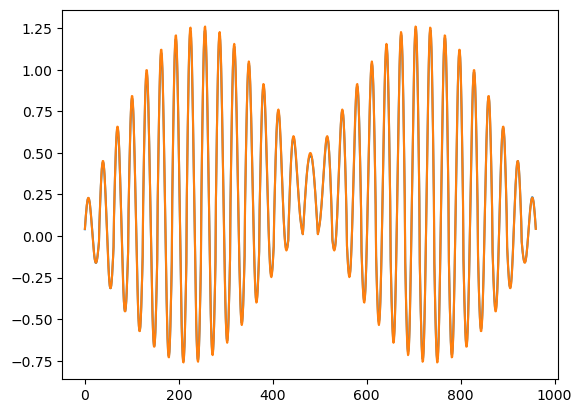

In [1228]:
plt.plot(sol_ROM.detach().numpy())
plt.plot(sol_truth)
#plt.plot(sol_classical)

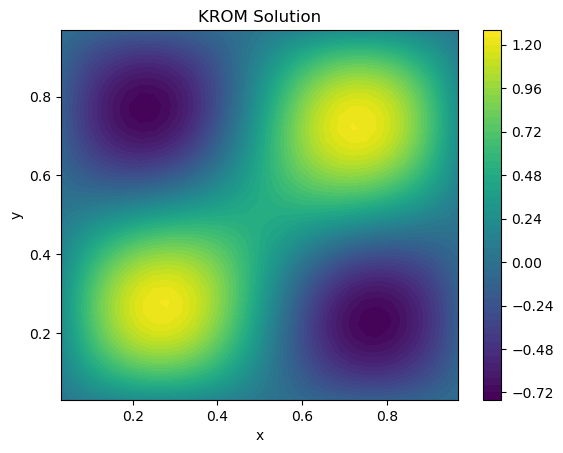

In [2181]:
cp = plt.contourf(X_int, Y_int, sol_ROM.detach().numpy().reshape((N_sqrt-1,N_sqrt-1)), levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('KROM Solution')
plt.show()

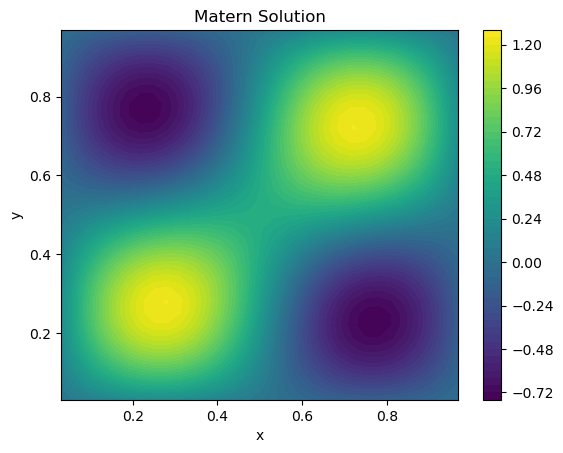

In [2197]:
cp = plt.contourf(X_int, Y_int, sol_ROM.detach().numpy().reshape((N_sqrt-1,N_sqrt-1)), levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Matern Solution')
plt.show()

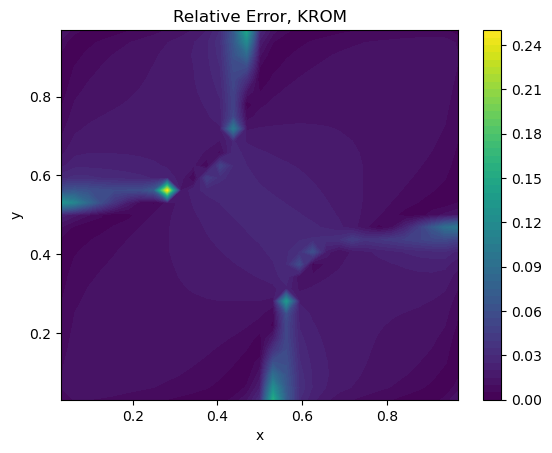

In [2182]:
rel_error = abs(sol_ROM.detach().numpy()-sol_truth.detach().numpy())/abs(sol_truth.detach().numpy())

cp = plt.contourf(X_int, Y_int,rel_error.reshape((N_sqrt-1,N_sqrt-1)), levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Relative Error, KROM')
plt.show()

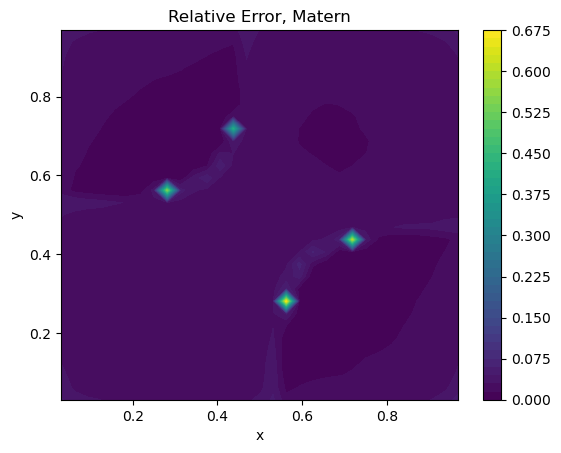

In [2195]:
rel_error = abs(sol_ROM.detach().numpy()-sol_truth.detach().numpy())/abs(sol_truth.detach().numpy())

cp = plt.contourf(X_int, Y_int,rel_error.reshape((N_sqrt-1,N_sqrt-1)), levels=50, cmap='viridis')
plt.colorbar(cp)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Relative Error, Matern')
plt.show()

In [ ]:
sol_ROM.detach().numpy()/sol_truth

In [ ]:
error_N_sol = [2.3347, 0.9682, 0.7280, 0.0803, 0.0738, 0.0498, 0.0448, 0.0400, 0.0406, 0.0425]

plt.plot(np.arange(1,11)*10,error_N_sol)
plt.xlabel('Number of Solutions')
plt.ylabel('Relative Error')

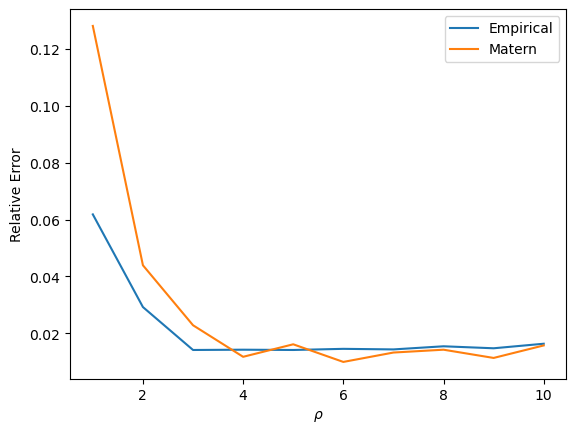

In [1724]:
error_rho = [[0.0618, 0.1281],
[0.0292, 0.0439],
[0.0141, 0.0228],
[0.0142, 0.0117],
[0.0141, 0.0161],
[0.0145, 0.0099],
[0.0143, 0.0132],
[0.0154, 0.0142],
[0.0147, 0.0113],
[0.0163, 0.0157]]
plt.plot(np.arange(1,11),error_rho)
plt.xlabel(r'$\rho$')
plt.ylabel('Relative Error')
plt.legend(['Empirical', 'Matern'])
#plt.title('rho vs. Number of Solutions')

Text(0, 0.5, '$\\log_4 (Error)$')

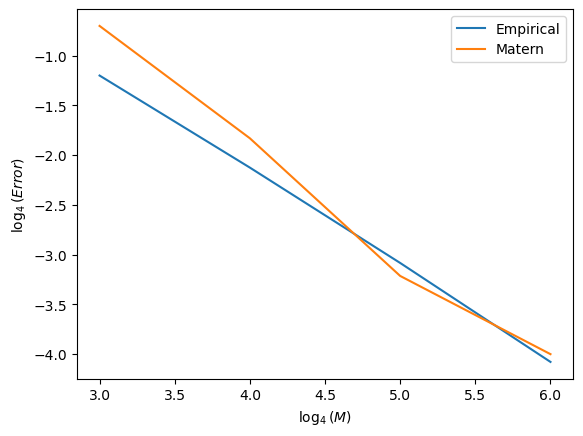

In [2536]:
error_M_points = np.array([[0.1894, 0.3782],
[0.0525, 0.0790],
[0.0139, 0.0116],
[0.0035, 0.0039]])
plt.plot(np.arange(3,7),np.log(error_M_points[:,0])/np.log(4))
plt.plot(np.arange(3,7),np.log(error_M_points[:,1])/np.log(4))
plt.legend(['Empirical','Matern'])
plt.xlabel(r'$\log_4 (M)$')
plt.ylabel(r'$\log_4 (Error)$')

In [ ]:
from scipy.spatial import KDTree  # Importing KDTree for efficient nearest-neighbor search
from dataclasses import dataclass
@dataclass
class Measurement:
    index: int
    l: float


class MaxHeap:

    def __init__(self, distances):
        self.maxsize = len(distances)
        self.size = self.maxsize
        self.Heap = [Measurement(index=-1, l=sys.maxsize)] \
                    + [Measurement(index=int(i) + 1, l=float(d)) for i, d in zip(range(self.maxsize), distances)]
        self.ids = [i for i in range(self.maxsize + 1)]  # the ith element's value represent the index of the original ith element in the current heap, 0 means deleted
        self.FRONT = 1
        self._build_max_heap()

    # Function to return the position of the parent for the node currently at pos
    def parent(self, pos):
        return pos // 2

    # Function to return the position of the left child for the node currently at pos
    def leftChild(self, pos):
        return 2 * pos

    # Function to return the position of the right child for the node currently at pos
    def rightChild(self, pos):
        return (2 * pos) + 1

    # Function that returns True if the passed node is a leaf node
    def isLeaf(self, pos):
        return pos > (self.size // 2) and pos <= self.size

    # Function to swap two nodes of the heap
    def swap(self, fpos, spos):
        i, j = self.Heap[fpos].index, self.Heap[spos].index
        self.Heap[fpos], self.Heap[spos], self.ids[i], self.ids[j] = self.Heap[spos], self.Heap[fpos], spos, fpos

    # Function to heapify the node at pos
    def _heapify_down(self, pos):
        # If the node is a non-leaf node and smaller than any of its children
        if not self.isLeaf(pos):
            left = self.leftChild(pos)
            right = self.rightChild(pos)
            largest = pos
 
            if left <= self.size and self.Heap[left].l > self.Heap[largest].l:
                largest = left
            if right <= self.size and self.Heap[right].l > self.Heap[largest].l:
                largest = right

            # Swap and continue heapifying if the current node is not the largest
            if largest != pos:
                self.swap(pos, largest)
                self._heapify_down(largest)

    # Function to remove and return the maximum element from the heap
    def pop(self):
        if self.size == 0:
            raise None
        popped = self.Heap[self.FRONT]
        self.Heap[self.FRONT] = self.Heap[self.size]
        self.ids[popped.index] = -1  # Remove this term
        self.size -= 1
        self._heapify_down(self.FRONT)
        return popped

    def decrease_key(self, k, new_distance):
        if k == -1:
            return 0 # the node specified in index is removed

        if self.Heap[k].l > new_distance:
            self.Heap[k].l = new_distance
            self._heapify_down(k)
        return 1

    def _build_max_heap(self):
        for i in range(self.size // 2, 0, -1):
            self._heapify_down(i)



def __reverse_maximin(x, initial = None):
    """Return the reverse maximin ordering and length scales."""
    n = x.size(0)
    indexes = torch.zeros(n, dtype=torch.int64)
    lengths = torch.zeros(n)

    # Arbitrarily select the first point
    if initial is None or initial.size(0) == 0:
        k = 0
        dists = torch.cdist(x, x[k : k + 1], p=2).flatten()
        indexes[-1] = k
        lengths[-1] = float('inf')
        start = n - 2
    else:
        initial_tree = KDTree(initial.numpy())
        dists, _ = initial_tree.query(x.numpy())
        dists = torch.tensor(dists)
        start = n - 1

    # Initialize tree and heap
    tree = KDTree(x.numpy())
    heap = MaxHeap(dists)

    for i in range(start, -1, -1):
        # Select point with the largest minimum distance
        popped = heap.pop()
        k = popped.index - 1
        lk = popped.l
        indexes[i] = k
        lengths[i] = lk
        # Update distances to all points within the distance `lk`
        js = tree.query_ball_point(x[k].numpy(), lk)
        dists = torch.cdist(x[js], x[k:k + 1], p=2).flatten()
        for index, j in enumerate(js):
            heap.decrease_key(heap.ids[j+1], dists[index].item())

    return indexes, lengths


def maximin(x, initial = None):
    indices, lengths = __reverse_maximin(x, initial)
    return torch.flip(indices, dims=[0]), torch.flip(lengths, dims=[0])

def sparsity_diff(x, lengths, rho):
    """Compute the sparity pattern given the ordered x."""
    # O(n log^2 n + n s)
    tree, offset, length_scale = KDTree(x.numpy()), 0, lengths[0]
    sparsity = {}
    for j in range(len(x)):
        sparsity[j] = [offset + i for i in tree.query_ball_point(x[j], rho * lengths[j]) if offset + i <= j]
    return sparsity


In [ ]:
def __col(Theta, s, nugget =1e-5):
    """
    compute \Theta_{s, s}^{-1}e_j / \sqrt{e_j^T\Theta_{s, s}^{-1}e_j}

    A simple implementation is to invert \Theta_{s, s} directly using the following code

    m = torch.inverse(Theta[s][:, s])
    return m[:, -1] / torch.sqrt(m[-1, -1])

    However, it has some stability issues. When, \Theta_{s, s} is ill-conditioned, torch.inverse(Theta[s, s]) may not
    give us the accurate solution and e_j^T\Theta_{s, s}^{-1}e_j may be negative and torch.sqrt(m[-1, -1]) produces NaN value.
    
    Thus, instead, we use standard Cholesky directly on \Theta_{s, s}^{-1} and also adding a small nugget to prevent numerical issue
    """
    m = Theta[s][:, s] + nugget * torch.eye(len(s))
    
    L = torch.linalg.cholesky(m)
    ej = torch.zeros(len(s))  # Create a tensor of zeros
    ej[-1] = 1
    v = torch.cholesky_solve(ej.unsqueeze(-1), L, upper=False).squeeze(-1)
    if v[-1] < 0:
        raise ValueError(f"Negative value encountered for square root: {v[-1]}")
    vl = torch.sqrt(v[-1])
    return v / vl


def __cholesky(Theta, sparsity):
    n = Theta.shape[0]
    indptr = torch.cumsum(torch.tensor([0] + [len(sparsity[i]) for i in range(n)]), dim=0)
    total_nonzeros = indptr[-1].item()

    # Prepare storage for sparse matrix components
    data = torch.zeros(total_nonzeros, dtype=torch.float64)
    row_indices = torch.zeros(total_nonzeros, dtype=torch.int64)
    col_indices = torch.zeros(total_nonzeros, dtype=torch.int64)

    for i in range(n):
        s = sorted(sparsity[i])
        col_data = __col(Theta, s)
        start, end = indptr[i], indptr[i + 1]

        data[start:end] = col_data
        row_indices[start:end] = torch.tensor(s, dtype=torch.int64)
        col_indices[start:end] = i
        print(i)

    # Create sparse COO tensor
    indices = torch.vstack([row_indices, col_indices])
    sparse_cholesky = torch.sparse_coo_tensor(indices, data, size=(n, n))
    return sparse_cholesky



def sparse_cholesky(Theta, Perm, sparsity) -> torch.sparse_coo_tensor:
    reordered_Theta = Theta[Perm][:, Perm]
    return __cholesky(reordered_Theta, sparsity)

In [ ]:
# Compute sparse Cholesky factor
rho = 5
Perm, lengths = maximin(rearranged_grid)
lengths_extended = np.concatenate((lengths,lengths[-1]*np.ones(N_domain_tot)),axis=0)
Perm_extended = torch.concatenate((Perm,torch.arange(N,N+N_domain_tot)),axis=0)

extended_tensor = np.concatenate((grid[Perm],rearranged_grid[:N_domain_tot]),axis=0)
SE = sparsity_diff(torch.from_numpy(extended_tensor), lengths_extended, rho)

L_sparse = sparse_cholesky(K_Empirical, Perm_extended, SE).T

idx = L_sparse.coalesce().indices()      # shape (2, nnz): [row_indices; col_indices]
vals = L_sparse.coalesce().values()      # shape (nnz,)

# 2) Compute new row indices by applying your permutation
old_rows = idx[0]                      # original row for each nnz
new_rows = Perm_extended[old_rows]              # permuted row for each nnz

# 3) Reassemble the indices
new_idx = torch.stack([new_rows, idx[1]], dim=0)

# 4) Build the permuted sparse matrix D
#L_Empirical = torch.sparse_coo_tensor(new_idx, vals, (N+N_domain_tot, N+N_domain_tot)).coalesce()
L_Empirical = L_sparse